# 0. Imports

In [5]:
import re
from collections import Counter
from pathlib import Path

import faiss
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# 1. Download and Store Dataset

In [2]:
def ingest_reddit_data(subreddit_key: str, n_rows: int = 1_000_000, force_rerun: bool = False) -> Path:
    """
    Orchestrates the ETL process for a specific subreddit's comment data.
    
    Args:
        subreddit_key: Dictionary key from 'splits' (e.g., 'changemyview').
        n_rows: Maximum records to process for the local sample.
        force_rerun: If True, bypasses existence check and overwrites existing parquet file.
        
    Returns:
        Path to the processed Parquet file.
    """
    out_path = Path(f"data/processed/{subreddit_key}_sample.parquet")
    
    # Idempotency check: Skip heavy network I/O if the target file is already present
    if out_path.exists() and not force_rerun:
        print(f"Skipping ingestion: Local cache found at {out_path}")
        return out_path

    out_path.parent.mkdir(parents=True, exist_ok=True)

    # Define schema subset based on downstream analytical requirements
    feature_cols = [
        "author", "body", "created_utc", "id", "link_id", "name",
        "parent_id", "score", "controversiality", "total_awards_received"
    ]
    splits = {
    'changemyview': 'data/changemyview-*-of-*.parquet',
    }

    print(f"Streaming data from HuggingFace for: r/{subreddit_key}...")
    
    # Execute lazy-evaluated ETL pipeline
    try:
        (
            pl.scan_parquet(f"hf://datasets/HuggingFaceGECLM/REDDIT_comments/{splits[subreddit_key]}")
            .select(feature_cols)
            # Filter out deleted/removed content to maintain high data quality for NLP tasks
            .filter(~pl.col("body").is_in(["[deleted]", "[removed]"]))
            .limit(n_rows)
            # Stream directly to disk using ZSTD to balance compression ratio and write speed
            .sink_parquet(out_path, compression="zstd")
        )
        print(f"Successfully wrote {n_rows} rows to {out_path}")
    except KeyError:
        raise ValueError(f"Subreddit '{subreddit_key}' not found in defined splits.")
    except Exception as e:
        print(f"Pipeline failed: {e}")
        raise

    return out_path

# --- Execution Control ---
# Toggle 'force_rerun' if the upstream data schema changes or a larger sample is needed
OUT = ingest_reddit_data("changemyview", n_rows=1_000_000, force_rerun=False)

Streaming data from HuggingFace for: r/changemyview...
Successfully wrote 1000000 rows to data/processed/changemyview_sample.parquet


# 2. Load Data from Parquet File

In [6]:
df = (
    # Scan the metadata and define the lazy query plan
    pl.scan_parquet("data/processed/changemyview_clean_head.parquet")
      # Constrain sample size for rapid local prototyping
      .head(50000)
      # Trigger execution and load into memory
      .collect()
      # Bridge to Pandas for ecosystem compatibility
      .to_pandas()
)

# 3. Create Train and Test Dataset

### 3.1 Data Preprocessing, Temporal Splitting & Metadata Mapping

In [7]:
# --- 1. Data Cleaning & Type Casting ---

# Ensure text integrity by removing null observations in the primary feature
df = df.dropna(subset=["body"])

# Filter out anonymous/deleted accounts to maintain attribution quality
df = df[df["author"] != "[deleted]"]

# Normalize timestamps: Convert raw strings to numeric Unix seconds, then to datetime objects
# 'coerce' handles malformed strings by returning NaT, preventing pipeline crashes
df["created_utc"] = pd.to_numeric(df["created_utc"], errors="coerce")
df["date"] = pd.to_datetime(df["created_utc"], unit="s", errors="coerce")


# --- 2. Temporal Train/Test Split ---

# Use a temporal 80/20 split rather than a random shuffle to prevent 'look-ahead' bias.
# This simulates a real-world scenario where we predict future comments based on past data.
cutoff = df["created_utc"].quantile(0.8)

df_train = df[df["created_utc"] <= cutoff].copy()
df_test  = df[df["created_utc"] > cutoff].copy()


# --- 3. Metadata Mapping (Lookup Tables) ---

# Create lightweight author lookups for efficient O(1) retrieval.
# Mappings are scoped strictly within splits to enforce isolation and prevent leakage.
id2author_train = df_train.set_index("id")["author"].to_dict()
id2author_test  = df_test.set_index("id")["author"].to_dict()

### 3.2 Interaction Network Construction

In [8]:
def build_reply_pairs(df_split, id2author):
    """
    Constructs a positive interaction dataset by mapping comments to their parent authors.
    Filters for comment-to-comment replies and removes self-interactions.
    """
    # Reddit 'parent_id' prefixes: t1 = Comment, t3 = Link/Post.
    # We restrict analysis to comment-to-comment interactions to capture conversational dynamics.
    parent_comment_ids = df_split["parent_id"].astype(str)
    is_comment_reply = parent_comment_ids.str.startswith("t1_")
    df_r = df_split[is_comment_reply].copy()

    # Extract the raw 36-base ID by stripping the 't1_' type prefix for join compatibility
    df_r["parent_key"] = df_r["parent_id"].str.replace("^t1_", "", regex=True)

    # Resolve parent author identities via the provided lookup table (O(1) mapping)
    df_r["parent_author"] = df_r["parent_key"].map(id2author)

    # --- Data Integrity & Quality Filtering ---
    # 1. Drop replies where the parent comment falls outside the current split (boundary integrity)
    df_r = df_r.dropna(subset=["parent_author"])
    # 2. Exclude self-replies to ensure we only model interpersonal interactions
    df_r = df_r[df_r["author"] != df_r["parent_author"]]

    # Feature selection and renaming to standard (u, v) graph notation
    pairs_pos = df_r[["author", "parent_author", "created_utc", "link_id", "id", "parent_key"]].copy()
    pairs_pos = pairs_pos.rename(columns={
        "author": "u", 
        "parent_author": "v", 
        "id": "u_comment_id", 
        "parent_key": "v_comment_id"
    })
    
    # Label as positive instances for downstream binary classification
    pairs_pos["y"] = 1
    return pairs_pos

# Generate interaction sets; scoped within splits to prevent data leakage
pos_train = build_reply_pairs(df_train, id2author_train)
pos_test  = build_reply_pairs(df_test, id2author_test)

print(f"Positive samples - Train: {len(pos_train):,} | Test: {len(pos_test):,}")

Positive samples - Train: 21,337 | Test: 5,709


## Baselines

### Random Baseline

In [9]:
import random

# 1. Kandidatenmenge = alle User aus dem Training
all_users_train = set(pos_train["u"]).union(set(pos_train["v"]))
all_users_train = list(all_users_train)

def recommend_random(user, k=10, exclude_seen=True):
    """
    Recommend k random users.
    
    Args:
        user: source user
        k: number of recommendations
        exclude_seen: avoid recommending already interacted users (train)
    """
    if not exclude_seen:
        candidates = [u for u in all_users_train if u != user]
        return random.sample(candidates, k)

    # Users already interacted with in training
    seen = set(pos_train[pos_train["u"] == user]["v"].values)

    candidates = [
        u for u in all_users_train
        if u != user and u not in seen
    ]

    if len(candidates) < k:
        return candidates

    return random.sample(candidates, k)

In [10]:
def evaluate_random_precision_at_k(k=10):
    hits = 0
    total = 0

    test_grouped = pos_test.groupby("u")["v"].apply(set)

    for user, true_targets in test_grouped.items():
        recs = recommend_random(user, k=k)

        hits += len(set(recs) & true_targets)
        total += k

    precision = hits / total if total > 0 else 0
    return precision


print("Random Precision@10:", evaluate_random_precision_at_k(k=10))

Random Precision@10: 0.0006951340615690168


### Popularity Baseline

In [11]:
from collections import defaultdict

# 1. Compute popularity scores from TRAIN only
popularity_scores = (
    pos_train["v"]
    .value_counts()
    .to_dict()
)

# 2. Global ranking of users by popularity
global_pop_ranking = sorted(
    popularity_scores.keys(),
    key=lambda x: popularity_scores[x],
    reverse=True
)


def recommend_popularity(user, k=10, exclude_seen=True):
    """
    Recommend top-k most popular users.
    
    Args:
        user: source user
        k: number of recommendations
        exclude_seen: avoid recommending already interacted users (train)
    """
    if not exclude_seen:
        return global_pop_ranking[:k]

    # Users already interacted with in training
    seen = set(pos_train[pos_train["u"] == user]["v"].values)

    recs = []
    for candidate in global_pop_ranking:
        if candidate != user and candidate not in seen:
            recs.append(candidate)
        if len(recs) == k:
            break

    return recs

In [12]:
def evaluate_precision_at_k(k=10):
    hits = 0
    total = 0

    # Group test interactions by user
    test_grouped = pos_test.groupby("u")["v"].apply(set)

    for user, true_targets in test_grouped.items():
        recs = recommend_popularity(user, k=k)

        hits += len(set(recs) & true_targets)
        total += k

    precision = hits / total if total > 0 else 0
    return precision


print("Popularity Precision@10:", evaluate_precision_at_k(k=10))

Popularity Precision@10: 0.014597815292949354


### Common Neighbor Baseline

In [13]:
from collections import defaultdict

# 1. Build an Adjacency List from the TRAIN set
# We treat the network as undirected to find "friends of friends" (mutual interactors)
adj = defaultdict(set)
for u, v in zip(pos_train["u"], pos_train["v"]):
    adj[u].add(v)
    adj[v].add(u)

def recommend_common_neighbors(user, k=10, exclude_seen=True):
    """
    Recommend users based on the number of shared interaction partners (Common Neighbors).
    
    Args:
        user: The source user for whom to generate recommendations.
        k: Number of recommendations to return.
        exclude_seen: If True, prevents recommending users already interacted with in training.
    """
    if user not in adj:
        # Cold-start: If the user has no history, no neighbors can be found
        return []

    user_neighbors = adj[user]
    candidate_scores = defaultdict(int)
    
    # Traverse to neighbors (friends) and then to their neighbors (friends of friends)
    for neighbor in user_neighbors:
        for fof in adj[neighbor]: # Friend of a Friend
            if fof != user:
                # Increment score for every shared path (common neighbor)
                candidate_scores[fof] += 1
    
    # Filter: Remove users the target user has already interacted with in the training set
    if exclude_seen:
        for seen_user in user_neighbors:
            if seen_user in candidate_scores:
                del candidate_scores[seen_user]
                
    # Sort candidates by the number of common neighbors in descending order
    sorted_recs = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
    return [rec[0] for rec in sorted_recs[:k]]



In [14]:
def evaluate_cn_precision_at_k(k=10):
    """
    Evaluate the Precision@K for the Common Neighbors baseline on the test set.
    """
    hits = 0
    total = 0

    # Group ground-truth test interactions by source user
    test_grouped = pos_test.groupby("u")["v"].apply(set)

    for user, true_targets in test_grouped.items():
        recs = recommend_common_neighbors(user, k=k)
        
        if not recs:
            # If no common neighbors are found (graph sparsity), it counts as 0 hits
            total += k
            continue

        # Count how many recommendations appear in the actual test set
        hits += len(set(recs) & true_targets)
        total += k

    precision = hits / total if total > 0 else 0
    return precision

# --- Execution ---
print("Common Neighbors Precision@10:", evaluate_cn_precision_at_k(k=10))

Common Neighbors Precision@10: 0.003972194637537239


### Data Visualization

In [57]:
import networkx as nx
import matplotlib
# Force a non-interactive backend so it doesn't wait for a window
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

def save_network_graph(df, filename="network_structure.png"):
    # 1. Create Graph from the first 500 rows for speed
    # 'u' is the follower/replier, 'v' is the followed/author
    G = nx.from_pandas_edgelist(df.head(500), source='u', target='v')
    
    print(f"Processing {G.number_of_nodes()} nodes...")

    # 2. Setup Figure
    plt.figure(figsize=(12, 12))
    
    # 3. Calculate Layout
    # k: optimal distance between nodes. Increase to spread them out.
    pos = nx.spring_layout(G, k=0.1, iterations=20, seed=42)
    
    # 4. Draw Components
    # Draw edges first (background)
    nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
    # Draw nodes on top
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color='blue', alpha=0.6)
    
    plt.title("Static Interaction Network")
    plt.axis('off')
    
    # 5. Save directly to disk
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close() # Close to free up memory
    print(f"DONE! Please check your folder for the file: {filename}")

# Call the function
save_network_graph(pos_train)

Processing 235 nodes...
DONE! Please check your folder for the file: network_structure.png


In [58]:
import networkx as nx
from pyvis.network import Network

# 1. Create a graph object from the top interactions in the training set
G = nx.from_pandas_edgelist(pos_train.head(1000), source='u', target='v')

# 2. Initialize the Pyvis Network object
# 'notebook=True' allows it to run in environments like Jupyter
# 'directed=True' reflects the nature of Reddit replies (User A replies to User B)
net = Network(notebook=True, directed=True, bgcolor='#222222', font_color='white')

# 3. Import the NetworkX graph into the Pyvis visualization tool
net.from_nx(G)

# 4. Generate and save the interactive HTML file
# This will create 'reddit_graph.html' in your current working directory
net.show("reddit_graph.html")

reddit_graph.html


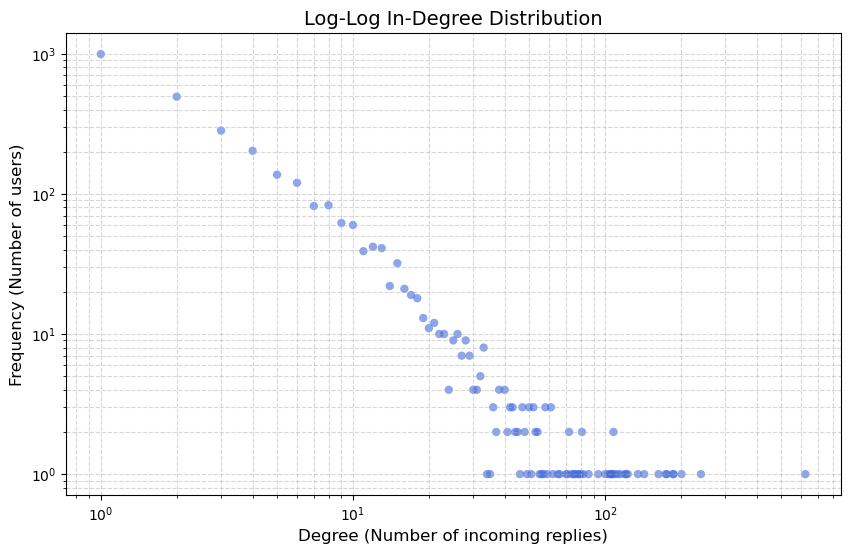

In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_log_log_degree_distribution(df):
    # 1. Calculate the In-Degree (how many replies each user 'v' received)
    in_degree_counts = df['v'].value_counts()
    
    # 2. Count the frequency of each degree
    # (e.g., how many users have exactly 1 reply, how many have 2, etc.)
    degree_frequencies = Counter(in_degree_counts)
    
    # Extract x (degree) and y (frequency)
    degrees = list(degree_frequencies.keys())
    counts = list(degree_frequencies.values())

    # 3. Create the Plot
    plt.figure(figsize=(10, 6))
    
    # Use a scatter plot for log-log to see the distribution clearly
    plt.scatter(degrees, counts, alpha=0.6, color='royalblue', edgecolors='none')
    
    # Set both axes to log scale
    plt.xscale('log')
    plt.yscale('log')
    
    # Formatting
    plt.title('Log-Log In-Degree Distribution', fontsize=14)
    plt.xlabel('Degree (Number of incoming replies)', fontsize=12)
    plt.ylabel('Frequency (Number of users)', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.show()

# Call the function with your training data
plot_log_log_degree_distribution(pos_train)

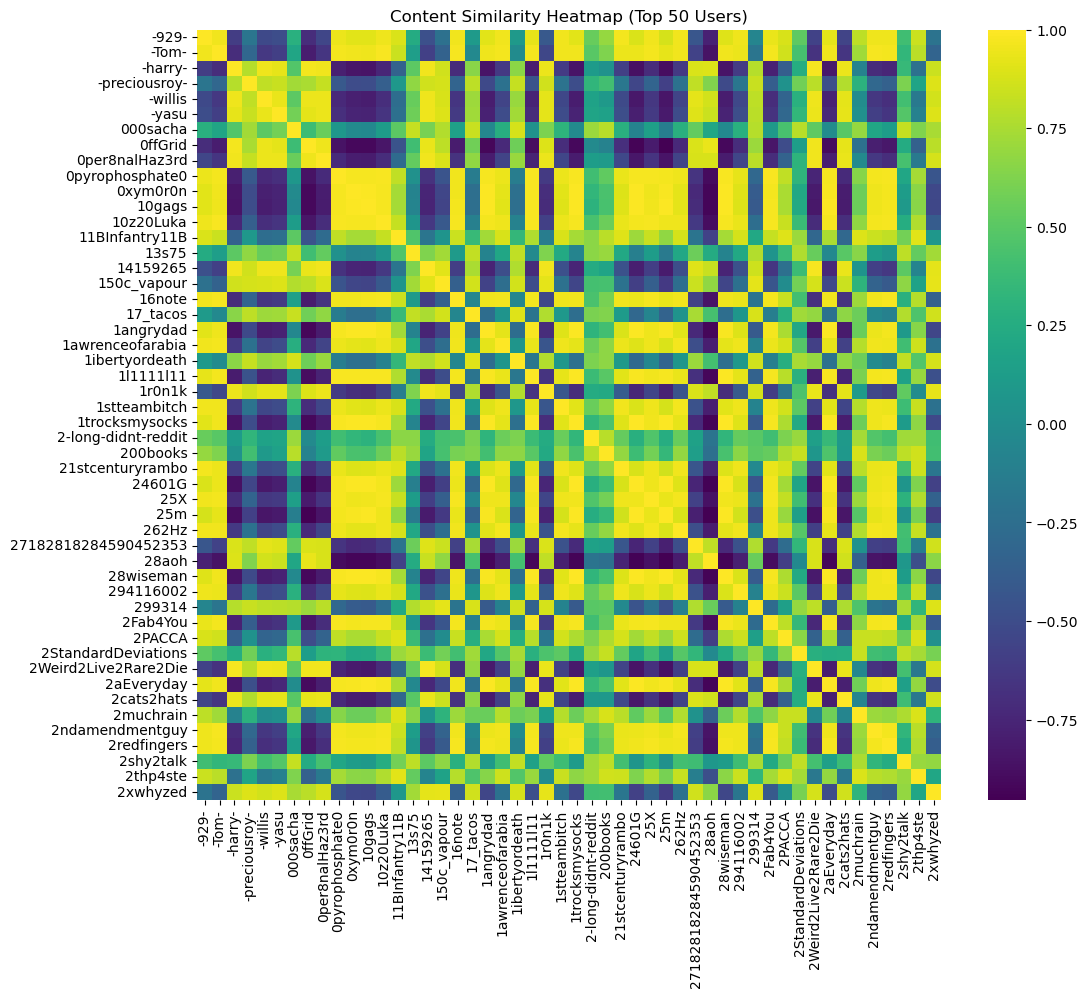

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_content_similarity_heatmap(embeddings_matrix, user_id_list, n_users=50):
    # Select the top N users (e.g., the most active ones)
    subset_matrix = embeddings_matrix[:n_users]
    subset_labels = user_id_list[:n_users]

    # Calculate Cosine Similarity (since vectors are L2 normalized, 
    # Dot Product = Cosine Similarity)
    sim_matrix = np.dot(subset_matrix, subset_matrix.T)

    plt.figure(figsize=(12, 10))
    sns.heatmap(sim_matrix, xticklabels=subset_labels, yticklabels=subset_labels, 
                cmap='viridis', annot=False)
    plt.title(f'Content Similarity Heatmap (Top {n_users} Users)')
    plt.show()

# Call with your FAISS-ready matrix and ID list
plot_content_similarity_heatmap(embeddings_matrix, user_id_list)

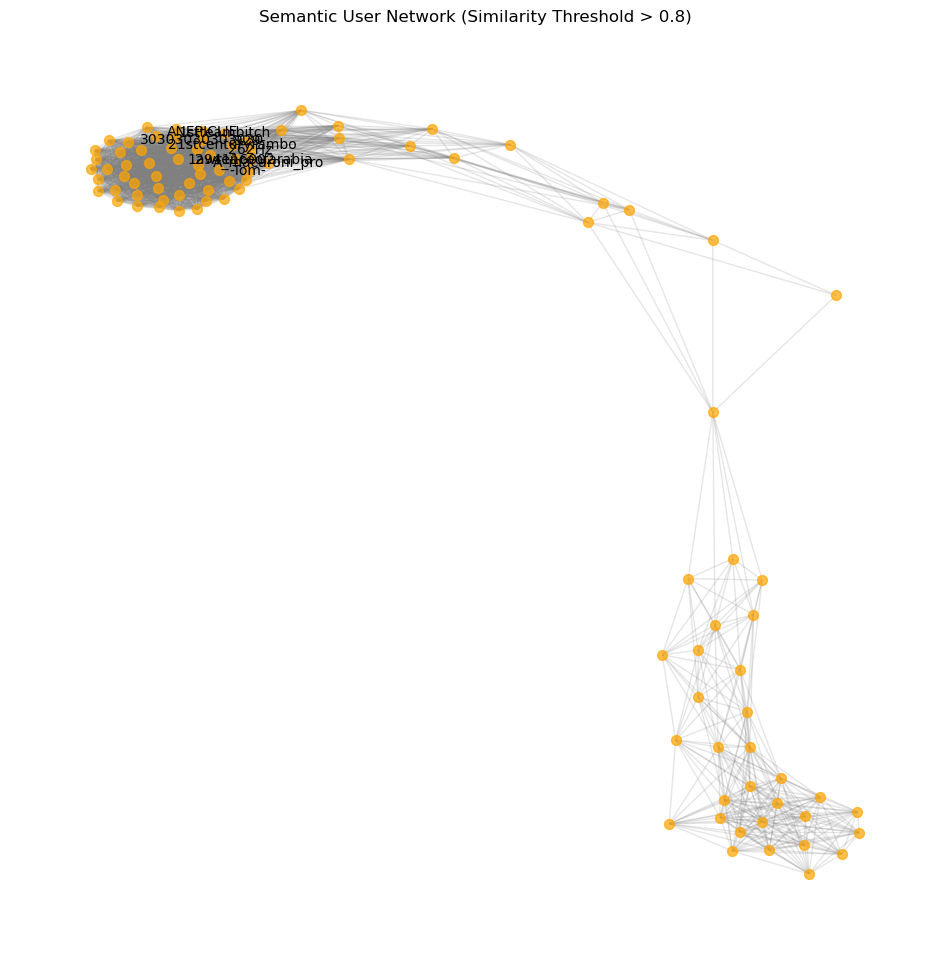

In [36]:
import networkx as nx

def plot_semantic_network(embeddings_matrix, user_id_list, n_users=100, threshold=0.8):
    subset_matrix = embeddings_matrix[:n_users]
    subset_labels = user_id_list[:n_users]
    
    # Compute similarity
    sim_matrix = np.dot(subset_matrix, subset_matrix.T)
    
    G = nx.Graph()
    for i in range(len(subset_labels)):
        for j in range(i + 1, len(subset_labels)):
            if sim_matrix[i, j] > threshold:
                G.add_edge(subset_labels[i], subset_labels[j], weight=sim_matrix[i, j])
    
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.15, seed=42)
    
    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='orange', alpha=0.7)
    nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')
    
    # Only label highly connected nodes to keep it clean
    centrality = nx.degree_centrality(G)
    top_nodes = sorted(centrality, key=centrality.get, reverse=True)[:10]
    labels = {node: node for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family='sans-serif')

    plt.title(f"Semantic User Network (Similarity Threshold > {threshold})")
    plt.axis('off')
    plt.show()

plot_semantic_network(embeddings_matrix, user_id_list)

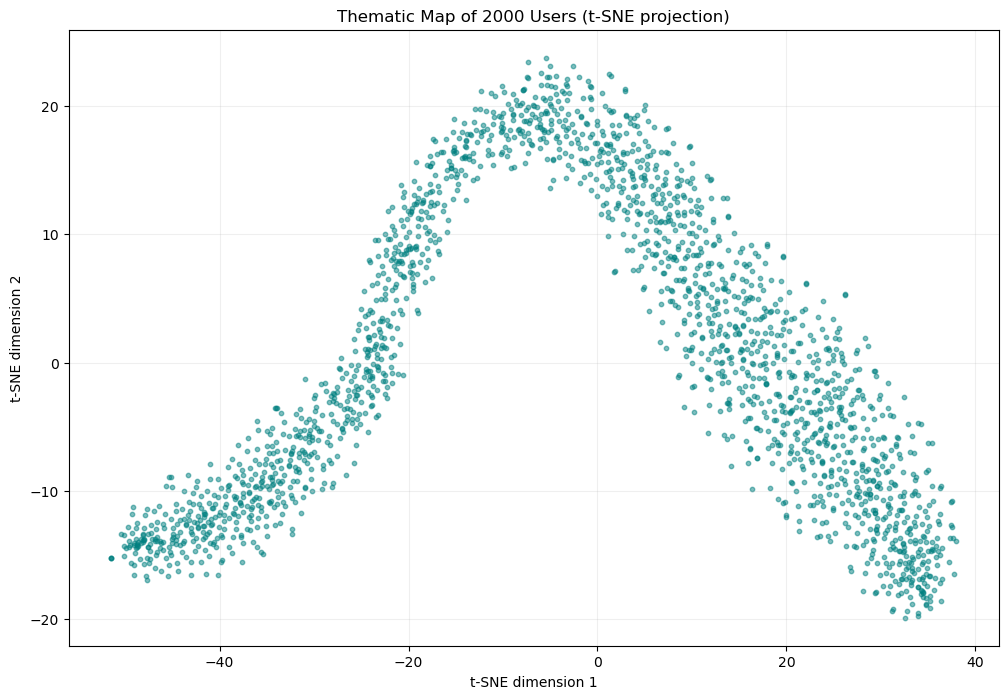

In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne_thematic_map(embeddings_matrix, n_users=2000):
    # Reduce dimensionality to 2D
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
    # We use a subset because t-SNE is computationally expensive
    reduced_embeddings = tsne.fit_transform(embeddings_matrix[:n_users])

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.5, s=10, c='teal')
    
    plt.title(f'Thematic Map of {n_users} Users (t-SNE projection)')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.grid(True, alpha=0.2)
    plt.show()

# Aufrufen mit deiner Matrix aus dem Notebook
plot_tsne_thematic_map(embeddings_matrix)

/var/folders/95/9n1yqcy54lx4gjg240ms6gxh0000gn/T/ipykernel_46519/3625238687.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', num_communities)


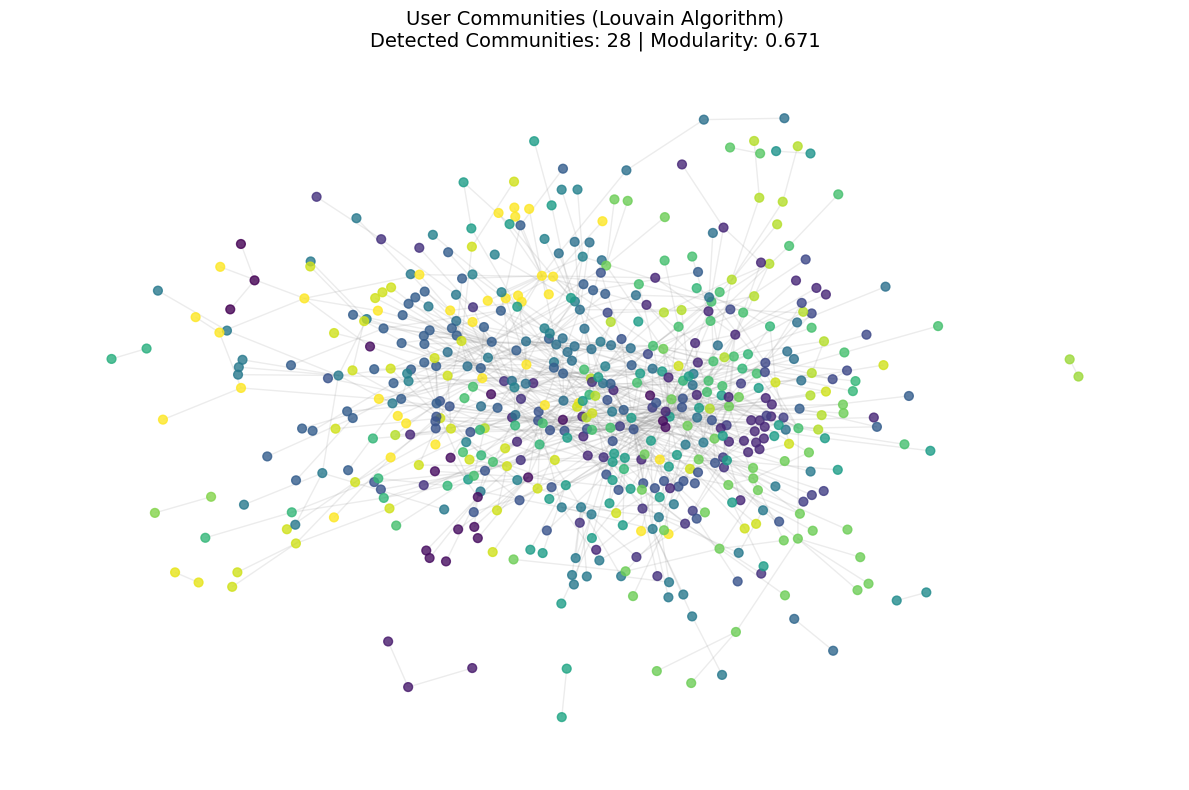

In [48]:
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt

def plot_louvain_communities(df, max_edges=2000):
    """
    Detects and visualizes structural user communities using the Louvain algorithm.
    """
    # 1. Create an undirected graph from the interaction data
    # Using a subset for better visualization clarity
    G = nx.from_pandas_edgelist(df.head(max_edges), source='u', target='v')
    
    # 2. Compute the best partition using the Louvain modularity algorithm
    # This assigns each user node to a specific community ID
    partition = community_louvain.best_partition(G)
    
    # 3. Calculate the graph layout (Force-Directed/Spring Layout)
    # The 'k' parameter controls the distance between nodes
    pos = nx.spring_layout(G, k=0.12, seed=42)
    
    # 4. Prepare the visualization
    plt.figure(figsize=(12, 8))
    
    # Map community IDs to a color palette
    num_communities = max(partition.values()) + 1
    cmap = plt.cm.get_cmap('viridis', num_communities)
    
    # Draw nodes: colored by their assigned community
    nx.draw_networkx_nodes(G, pos, partition.keys(), 
                           node_size=40,
                           node_color=list(partition.values()), 
                           cmap=cmap, 
                           alpha=0.8)
    
    # Draw edges: keeping them subtle to highlight the nodes
    nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='gray')
    
    # Calculate Modularity Score (measures the strength of the community structure)
    modularity = community_louvain.modularity(partition, G)
    
    plt.title(f"User Communities (Louvain Algorithm)\nDetected Communities: {num_communities} | Modularity: {modularity:.3f}", 
              fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Execute with your training interactions
plot_louvain_communities(pos_train)

In [44]:
%pip install python-louvain

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'python-louvain' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'python-louvain'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=c3fb80dd9d613950f873c5e58f0d103568096ca6773d3c7131d8a9957a251386
  Stored in directory: /Users/jan/Library/Caches/pip/wheels/d0/b0/d7/6dd26c3817810fa379088eaeb755a01d9a2a411c37632079d1
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.


In [18]:
# --- Graph Diagnostics: Sparsity & Degree Distribution ---

# Calculate the ratio of users who engaged in at least one reply
pos_users = set(pos_train["u"]) | set(pos_train["v"])
all_users = set(df_train["author"].dropna().unique())
print(f"Engagement Coverage: {len(pos_users)} / {len(all_users)} users with interactions")

# Analyze the 'Out-Degree' (number of replies sent per user)
print("\nReplies per user statistics:")
print(pos_train.groupby("u").size().describe())

Engagement Coverage: 3699 / 4703 users with interactions

Replies per user statistics:
count    3334.000000
mean        6.399820
std        19.591324
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       661.000000
dtype: float64


### 3.3 Negative Sampling Strategy

In [19]:
def build_hard_negatives(df_split, pos_pairs, k_per_pos=2, seed=42):
    """
    Generates 'hard' negative samples for link prediction by identifying potential 
    interactions that did NOT occur within the same discussion thread context.
    """
    # Initialize a BitGenerator for reproducible stochastic sampling
    rng = np.random.default_rng(seed)

    # 1) Contextual Mapping: Identify all active participants per discussion thread (link_id).
    # This defines our 'closed-world' candidate pool for each observation.
    thread_users = (
        df_split.groupby("link_id")["author"]
        .apply(lambda s: set(s.dropna()))
        .to_dict()
    )

    # 2) Network Topology: Extract existing interaction edges in (u, v) space.
    # We treat edges as symmetric to prevent sampling reciprocal replies as negatives,
    # which would introduce label noise.
    reply_edges = set(zip(pos_pairs["u"], pos_pairs["v"]))
    reply_edges_sym = reply_edges | {(v, u) for (u, v) in reply_edges}

    neg_rows = []
    # Project to minimal feature set to reduce overhead during iteration
    pos_pairs_small = pos_pairs[["u", "v", "link_id"]].copy()

    for u, v, link_id in pos_pairs_small.itertuples(index=False):
        users = list(thread_users.get(link_id, []))
        if len(users) <= 1:
            continue

        # Candidate Filtering: 
        # Target users in the same thread (high-signal 'hard' negatives) excluding the source 'u'
        cand = [x for x in users if x != u]
        if not cand:
            continue

        # Collision Avoidance: Remove candidates where a ground-truth interaction (u, x) exists
        cand = [x for x in cand if (u, x) not in reply_edges_sym]
        if not cand:
            continue

        # Stochastic Sampling: Select 'k' negatives per positive to maintain class ratio
        take = min(k_per_pos, len(cand))
        sampled = rng.choice(cand, size=take, replace=False)

        for x in sampled:
            neg_rows.append((u, x, link_id, 0))

    return pd.DataFrame(neg_rows, columns=["u", "v", "link_id", "y"])

# --- Triplet Dataset Assembly ---

def build_triplets_from_hard_negatives(pos_pairs, neg_pairs, seed=42):
    """
    Constructs triplets (u, v_pos, v_neg) for metric learning.
    For each positive interaction (u, v_pos), sample one hard negative v_neg
    from the same thread context.
    """
    rng = np.random.default_rng(seed)

    # Map u → list of negative candidates
    neg_map = (
        neg_pairs.groupby("u")["v"]
        .apply(list)
        .to_dict()
    )

    triplets = []

    for u, v_pos, link_id in pos_pairs[["u", "v", "link_id"]].itertuples(index=False):
        neg_candidates = neg_map.get(u, [])
        if not neg_candidates:
            continue

        # Sample one hard negative for this positive
        v_neg = rng.choice(neg_candidates)

        triplets.append((u, v_pos, v_neg, link_id))

    return pd.DataFrame(
        triplets,
        columns=["u", "v_pos", "v_neg", "link_id"]
    )


# --- Generate hard negatives (unchanged) ---
neg_train = build_hard_negatives(df_train, pos_train, k_per_pos=2)
neg_test  = build_hard_negatives(df_test,  pos_test,  k_per_pos=2)

# --- Build triplets ---
triplets_train = build_triplets_from_hard_negatives(pos_train, neg_train)
triplets_test  = build_triplets_from_hard_negatives(pos_test,  neg_test)

print("Triplets Train:", len(triplets_train))
print("Triplets Test:", len(triplets_test))
print(triplets_train.head())


Triplets Train: 21253
Triplets Test: 5666
                 u                 v_pos            v_neg    link_id
0        Jaberkaty  Thompson_S_Sweetback  ancillarynipple  t3_16ralh
1  ancillarynipple  Thompson_S_Sweetback        Jaberkaty  t3_16ralh
2  ancillarynipple  Thompson_S_Sweetback        Jaberkaty  t3_16ralh
3           llatia             gchase723          banebot  t3_16s6jg
4     cardswsbound                 nix0n           llatia  t3_16rzx1


In [20]:
def test_triplet_integrity(triplets, pos_df, neg_df):
    """
    Comprehensive suite to verify triplet logic and data leakage.
    """
    # 1. Structural Check
    assert not triplets.isnull().values.any(), "Triplets contain NaN values"
    
    # 2. Contextual Integrity: v_neg must actually exist in the negative pool for that user
    # This ensures rng.choice didn't pull a random user from the wrong context
    u_to_negs = neg_df.groupby("u")["v"].apply(set).to_dict()
    
    for row in triplets.itertuples():
        # Check: v_pos and v_neg must be different
        assert row.v_pos != row.v_neg, f"Anchor {row.u} has identical Pos/Neg target"
        
        # Check: anchor cannot be its own target
        assert row.u != row.v_pos, f"Self-loop found in positive: {row.u}"
        assert row.u != row.v_neg, f"Self-loop found in negative: {row.u}"
        
        # Check: v_neg must be a valid 'hard' negative from the pool
        valid_negs = u_to_negs.get(row.u, set())
        assert row.v_neg in valid_negs, f"User {row.v_neg} is not a valid hard negative for {row.u}"

    # 3. Label Leakage: Ensure v_neg is NEVER a real positive for that user
    # (Symmetric check to be extra safe)
    pos_edges = set(zip(pos_df["u"], pos_df["v"]))
    pos_edges_sym = pos_edges | {(v, u) for (u, v) in pos_edges}
    
    triplet_neg_edges = set(zip(triplets["u"], triplets["v_neg"]))
    overlap = triplet_neg_edges.intersection(pos_edges_sym)
    
    assert len(overlap) == 0, f"Leakage detected! {len(overlap)} 'negatives' are actually real interactions."

    print("✅ All Triplet Integrity Tests Passed!")

# Run the test
test_triplet_integrity(triplets_train, pos_train, neg_train)

✅ All Triplet Integrity Tests Passed!


### 3.4 User Textual Profile Construction

In [21]:
# --- 1. Corpus Preparation & Leakage Prevention ---

# Isolate training and testing text to ensure that future comments do not 
# influence the historical representations of users in the training set.
df_train_text = df_train.dropna(subset=["body", "id"]).copy()
df_test_text = df_test.dropna(subset=["body", "id"]).copy()

# (Optional) Heuristic: Filter for active users to ensure embeddings have 
# sufficient signal (min 5 observations). 
# df_train_text = df_train_text.groupby("id").filter(lambda g: len(g) >= 5)

# --- 2. Temporal Aggregation (Feature Engineering) ---

# Construct a profile for each author.
# We join the most recent comments to capture the user's current interests/voice.
user_text_train = (
    df_train_text
    .sort_values("created_utc")             # Enforce chronology to correctly identify the 'tail'
    .groupby("author")["body"]
    # Hyperparameter: Concatenating the last 10 comments balances context vs. sequence length
    .apply(lambda s: " ".join(s.tail(10)))  
)

user_text_test = (
    df_test_text
    .sort_values("created_utc")
    .groupby("author")["body"]
    .apply(lambda s: " ".join(s.tail(10)))
)

# Convert to hash maps (dict) for O(1) lookup performance during the mapping phase
user_text_dict_train = user_text_train.to_dict()
user_text_dict_test = user_text_test.to_dict()

# --- 3. Coverage Analysis (Data Integrity Check) ---

# Quantify the 'Cold-Start' issue: users in the interaction pairs who lack 
# textual history. Significant missingness here indicates a sampling mismatch.
missing_train = triplets_train["u"].map(user_text_dict_train).isna().mean()
print(f"Missing text profile ratio (Train - Source User): {missing_train:.2%}")

missing_test = triplets_test["u"].map(user_text_dict_test).isna().mean()
print(f"Missing text profile ratio (Test - Source User): {missing_test:.2%}")

Missing text profile ratio (Train - Source User): 0.00%
Missing text profile ratio (Test - Source User): 0.00%


In [22]:
# --- 1. Prepare Data Containers ---

# Create copies to prevent SettingWithCopy warnings and isolate split changes
triplets_train = triplets_train.copy()
triplets_test  = triplets_test.copy()

def attach_text(triplets, user_text_dict):
    """Adds historical text for source (u) and target (v) users."""
    
    # Map text profiles to user IDs
    triplets["text_u"] = triplets["u"].map(user_text_dict)
    triplets["text_v_pos"] = triplets["v_pos"].map(user_text_dict)
    triplets["text_v_neg"] = triplets["v_neg"].map(user_text_dict)

    # Remove observations missing text for either user to ensure a complete feature set
    return triplets.dropna(subset=["text_u", "text_v_pos", "text_v_neg"])

# --- 2. Execute Merge & Cleanup ---

triplets_train_txt = attach_text(triplets_train, user_text_dict_train)
triplets_test_txt  = attach_text(triplets_test,  user_text_dict_test)

# --- 3. Progress Check ---

# Log row counts to monitor data loss during the mapping/dropping process
print(f"Train Retention: {len(triplets_train):,} -> {len(triplets_train_txt):,}")
print(f"Test Retention:  {len(triplets_test):,} -> {len(triplets_test_txt):,}")

Train Retention: 21,253 -> 21,253
Test Retention:  5,666 -> 5,666


### 3.5 Save Train and Test Datasets

In [12]:
triplets_train_txt.to_parquet("data/processed/train_triplets_txt.parquet", index=False)
triplets_test_txt.to_parquet("data/processed/test_triplets_txt.parquet", index=False)

# 4. Train CNN

### 4.1 Create Vocabulary

In [23]:
# Define a simple regex to extract word-level tokens (alphabetic only)
TOKEN_RE = re.compile(r"[A-Za-z']+")

def tokenize(text: str):
    """Lowercases and extracts valid word tokens from raw text."""
    return TOKEN_RE.findall(text.lower())

# Constraints for memory efficiency and noise reduction
MAX_VOCAB = 50_000
MIN_FREQ = 2

# Build frequency distribution from training corpus only to prevent leakage
counter = Counter()
for t in triplets_train_txt["text_u"].tolist():
    counter.update(tokenize(t))
for t in triplets_train_txt["text_v_pos"].tolist():
    counter.update(tokenize(t))
for t in triplets_train_txt["text_v_neg"].tolist():
    counter.update(tokenize(t))

# Reserved tokens for sequence padding and out-of-vocabulary terms
PAD = "<pad>"
UNK = "<unk>"

# Initialize vocabulary with reserved indices
vocab = {PAD: 0, UNK: 1}

# Populate vocabulary with the most frequent terms meeting the frequency threshold
for w, c in counter.most_common(MAX_VOCAB):
    if c < MIN_FREQ:
        break
    vocab[w] = len(vocab)

pad_id = vocab[PAD]
unk_id = vocab[UNK]

print(f"Final Vocab Size: {len(vocab):,}")

Final Vocab Size: 37,536


### 4.2 Dataset Definition & User Text Encoding

In [24]:
# Fixed sequence length to ensure uniform input dimensions for the model
MAX_LEN = 256  

def encode(text: str):
    """
    Converts raw text into a list of integer IDs.
    Unknown words are mapped to 'unk_id' and sequences are truncated to MAX_LEN.
    """
    ids = [vocab.get(w, unk_id) for w in tokenize(text)]
    return ids[:MAX_LEN]

class TripletDataset(Dataset):
    """
    Custom PyTorch Dataset to serve (u, v_pos, v_neg) triplets, their respective 
    encoded histories, and the binary interaction label.
    """
    def __init__(self, df_triplets):
        self.u = df_triplets["u"].tolist()
        self.v_pos = df_triplets["v_pos"].tolist()
        self.v_neg = df_triplets["v_neg"].tolist()
        self.u_texts = df_triplets["text_u"].tolist()
        self.v_pos_texts = df_triplets["text_v_pos"].tolist()
        self.v_neg_texts = df_triplets["text_v_neg"].tolist()

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        # Returns raw IDs and encoded text sequences for the given index
        return (
            self.u[idx],
            self.v_pos[idx],
            self.v_neg[idx],
            encode(self.u_texts[idx]),
            encode(self.v_pos_texts[idx]),
            encode(self.v_neg_texts[idx]),
        )

In [25]:
def collate_fn(batch):
    """
    Dynamic padding: Aligns sequences within a batch to the length of 
    the longest sequence found in that specific batch.
    """
    # Unpack columns from the batch of tuples
    u, v_pos, v_neg, u_seqs, v_pos_seqs, v_neg_seqs = zip(*batch)

    # Track original lengths for masking or sequence packing
    u_lens = torch.tensor([len(s) for s in u_seqs], dtype=torch.long)
    v_pos_lens = torch.tensor([len(s) for s in v_pos_seqs], dtype=torch.long)
    v_neg_lens = torch.tensor([len(s) for s in v_neg_seqs], dtype=torch.long)

    # Determine batch-wide maximum dimensions
    max_u = max(u_lens).item()
    max_v_pos = max(v_pos_lens).item()
    max_v_neg = max(v_neg_lens).item()

    # Initialize tensors filled with the PAD token
    u_tensor = torch.full((len(batch), max_u), pad_id, dtype=torch.long)
    v_pos_tensor = torch.full((len(batch), max_v_pos), pad_id, dtype=torch.long)
    v_neg_tensor = torch.full((len(batch), max_v_neg), pad_id, dtype=torch.long)

    # Copy sequence data into the padded containers
    for i, s in enumerate(u_seqs):
        u_tensor[i, :len(s)] = torch.tensor(s, dtype=torch.long) 
        
    for i, s in enumerate(v_pos_seqs):
        v_pos_tensor[i, :len(s)] = torch.tensor(s, dtype=torch.long) 
    
    for i, s in enumerate(v_neg_seqs):
        v_neg_tensor[i, :len(s)] = torch.tensor(s, dtype=torch.long) 

    return list(u), list(v_pos), list(v_neg), u_tensor, v_pos_tensor, v_neg_tensor, u_lens, v_pos_lens, v_neg_lens

### 4.3 Data Loader Initilization

In [26]:
# Number of samples processed before the model updates its internal parameters
BATCH_SIZE = 128

# Instantiate dataset objects for training and evaluation
train_ds = TripletDataset(triplets_train_txt)
test_ds  = TripletDataset(triplets_test_txt)

# Training Loader: Shuffle enabled to prevent the model from learning the order of samples
train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn
)

# Testing Loader: Shuffle disabled to ensure consistent, reproducible evaluation
test_loader = DataLoader(
    test_ds,  
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

### 4.4 Create Siamese CNN

##### 4.4.1 Create Text Encoder to build user embeddings

In [27]:
class TextCNNEncoder(nn.Module):
    """
    Multi-kernel CNN for extracting hierarchical n-gram features from text.
    Outputs a normalized embedding representing a user's linguistic style.
    """
    def __init__(self, vocab_size, emb_dim=128, num_filters=128, kernel_sizes=(3,4,5), out_dim=128, pad_idx=0, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        
        # Parallel convolutional layers to capture varied phrase lengths
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=emb_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), out_dim)

    def forward(self, x):
        # x: [Batch, Sequence_Length]
        emb = self.embedding(x)            
        emb = emb.transpose(1, 2)          # Align dimensions for 1D convolution [B, E, T]

        conv_outs = []
        for conv in self.convs:
            # Apply convolution and non-linearity
            h = F.relu(conv(emb))          
            # Global Max Pooling: Extract the most salient feature per filter
            h = F.max_pool1d(h, kernel_size=h.size(2)).squeeze(2)  
            conv_outs.append(h)

        # Fusion of multi-scale features
        h = torch.cat(conv_outs, dim=1)    
        h = self.dropout(h)
        h = self.fc(h)                     
        
        # L2 Normalization to facilitate cosine similarity downstream
        h = F.normalize(h, p=2, dim=1)     
        return h

##### 4.4.2 Create Siamese Architecture

In [28]:
class SiameseCNN(nn.Module):
    """
    Siamese architecture for metric learning. 
    Uses a shared encoder to map the anchor, positive, and negative 
    samples into a common vector space.
    """
    def __init__(self, encoder: nn.Module):
        super().__init__()
        # The core Siamese principle: one encoder, shared weights.
        self.encoder = encoder

    def forward(self, u_tensor, v_pos_tensor, v_neg_tensor):
        # Pass all three through the identical encoder
        # This maps them to the same latent space for distance comparison
        emb_u = self.encoder(u_tensor)
        emb_pos = self.encoder(v_pos_tensor)
        emb_neg = self.encoder(v_neg_tensor)
        
        return emb_u, emb_pos, emb_neg

##### 4.4.3 Model Instatntiation & Device Allocation

In [29]:
# Automatically detect if a GPU is available for accelerated training
device = torch.device("mps" if torch.mps.is_available() else "cpu")

# Initialize the Feature Extractor (Encoder)
# We use a Multi-Kernel CNN to capture n-gram patterns of lengths 3, 4, and 5
encoder = TextCNNEncoder(
    vocab_size=len(vocab),  # Determined by the tokenizer in Section 6
    emb_dim=128,            # Dimensionality of the dense word vectors
    num_filters=128,        # Number of features to extract per kernel size
    kernel_sizes=(3, 4, 5), # Window sizes: Tri-grams, 4-grams, 5-grams
    out_dim=128,            # Final embedding size (compact semantic vector)
    pad_idx=pad_id,         # Index to ignore during embedding lookup (zero gradient)
    dropout=0.4,            # Regularization to prevent overfitting on specific phrases
)

# Wrap the encoder in the Siamese architecture for metric learning
# scale=10.0 expands the cosine range [-1, 1] to [-10, 10] for sharper probability gradients
model = SiameseCNN(encoder).to(device)

print(f"Model initialized on: {device}")

Model initialized on: mps


### 4.5 Train the CNN

In [30]:
# 1. New Criterion for Metric Learning
# p=2 indicates Euclidean distance. With your L2-normalized CNN, 
# this focuses the learning on the angular separation between users.
criterion = nn.TripletMarginLoss(margin=1.0, p=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

@torch.no_grad()
def eval_triplet_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    # Unpacking the three context-aware tensors
    for _, _, _, u_tensor, v_pos_tensor, v_neg_tensor, _, _, _ in loader:
        u_tensor = u_tensor.to(device)
        v_pos_tensor = v_pos_tensor.to(device)
        v_neg_tensor = v_neg_tensor.to(device)
        
        # Get embeddings from SiameseCNN
        emb_u, emb_v_pos, emb_v_neg = model(u_tensor, v_pos_tensor, v_neg_tensor)
        
        # Calculate Euclidean distances: d(anchor, positive) vs d(anchor, negative)
        dist_pos = torch.norm(emb_u - emb_v_pos, p=2, dim=1)
        dist_neg = torch.norm(emb_u - emb_v_neg, p=2, dim=1)
        
        # A successful "ranking" occurs when the positive is closer than the hard negative
        correct += (dist_pos < dist_neg).sum().item()
        total += u_tensor.size(0)

    return correct / total if total > 0 else 0.0

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    
    for _, _, _, u_tensor, v_pos_tensor, v_neg_tensor, _, _, _ in loader:
        u_tensor = u_tensor.to(device)
        v_pos_tensor = v_pos_tensor.to(device)
        v_neg_tensor = v_neg_tensor.to(device)

        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass through shared Siamese weights
        emb_u, emb_v_pos, emb_v_neg = model(u_tensor, v_pos_tensor, v_neg_tensor)
        
        # The loss pulls u closer to v_pos and pushes it away from v_neg
        loss = criterion(emb_u, emb_v_pos, emb_v_neg)
        
        loss.backward()
        # Gradient clipping prevents the "exploding gradient" problem in deep CNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * u_tensor.size(0)
        
    return total_loss / len(loader.dataset)

# --- Run Loop ---
EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader)
    
    # Accuracy is the % of triplets correctly ranked
    test_acc = eval_triplet_acc(model, test_loader)
    train_acc = eval_triplet_acc(model, train_loader)
    
    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.2%} | Test Acc: {test_acc:.2%}")

Epoch 01 | Loss: 0.9522 | Train Acc: 67.20% | Test Acc: 59.42%
Epoch 02 | Loss: 0.8375 | Train Acc: 71.05% | Test Acc: 60.17%
Epoch 03 | Loss: 0.7878 | Train Acc: 71.90% | Test Acc: 59.30%
Epoch 04 | Loss: 0.7548 | Train Acc: 70.96% | Test Acc: 55.54%
Epoch 05 | Loss: 0.7380 | Train Acc: 72.15% | Test Acc: 57.01%


### 5.1 Export the User "Galaxy" (Embeddings)

In [31]:
@torch.no_grad()
def generate_user_embeddings_batched(model, unique_user_df, batch_size=256):
    model.eval()
    user_ids = unique_user_df['author'].tolist()
    
    # 1. Pre-numericalize all texts using your existing 'encode' function
    # We pad them manually here to create a valid tensor
    all_seqs = [encode(t) for t in unique_user_df['body']]
    max_len = max(len(s) for s in all_seqs)
    
    padded_seqs = torch.full((len(all_seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(all_seqs):
        padded_seqs[i, :len(s)] = torch.tensor(s)

    # 2. Extract embeddings in batches using the GPU
    all_embs = []
    for i in range(0, len(padded_seqs), batch_size):
        batch = padded_seqs[i : i + batch_size].to(device)
        # Use ONLY the encoder; we don't need the Siamese wrapper for single users
        emb = model.encoder(batch) 
        all_embs.append(emb.cpu().numpy())
    
    full_matrix = np.vstack(all_embs)
    return {u_id: vec for u_id, vec in zip(user_ids, full_matrix)}, full_matrix

# --- How to call it ---
# Create the unique user list from your test or train data
unique_users = df.groupby("author")["body"].apply(lambda s: " ".join(s.tail(10))).reset_index()

user_vectors, embeddings_matrix = generate_user_embeddings_batched(model, unique_users)

### 5.2 Set up a Vector Search Index

In [32]:
# 1. Prepare data (FAISS requires float32)
embeddings_matrix = embeddings_matrix.astype('float32')
user_id_list = unique_users['author'].tolist()

# 2. Build the Index (IndexFlatIP = Inner Product)
# Since your CNN uses F.normalize, Inner Product is equivalent to Cosine Similarity.
d = embeddings_matrix.shape[1] 
index = faiss.IndexFlatIP(d) 
index.add(embeddings_matrix)

# 3. Create a lookup dictionary for user_vectors if you haven't already
# This allows O(1) retrieval of a vector by username
user_vectors = {u_id: embeddings_matrix[i] for i, u_id in enumerate(user_id_list)}

print(f"FAISS index built with {index.ntotal} users.")

FAISS index built with 5341 users.


### 5.3 Implement the Recommendation Function

In [33]:
def recommend_connections(query_user_id, k=5):
    """
    Finds the top k nearest neighbors using the FAISS index.
    """
    if query_user_id not in user_vectors:
        return []
    
    # 1. Get the query vector and reshape for FAISS [1, d]
    query_vec = user_vectors[query_user_id].reshape(1, -1).astype('float32')
    
    # 2. Search (k+1 because the query user will be their own closest neighbor)
    distances, indices = index.search(query_vec, k + 1)
    
    # 3. Map integer indices back to author strings
    # indices[0] contains the results for our single query
    results = []
    for idx in indices[0]:
        neighbor_id = user_id_list[idx]
        if neighbor_id != query_user_id:
            results.append(neighbor_id)
            
    return results[:k]

In [34]:
def test_recommendation(user_id):
    if user_id not in user_vectors:
        return "User not found"
    
    recs = recommend_connections(user_id, k=3)
    
    print(f"Target User ({user_id}) history sample: {unique_users[unique_users['author']==user_id]['body'].values[0][:100]}...")
    print("-" * 30)
    for i, rec_id in enumerate(recs):
        text = unique_users[unique_users['author']==rec_id]['body'].values[0][:100]
        print(f"Rec {i+1}: {rec_id} | Text: {text}...")

# Example call
test_recommendation(user_id_list[10])

Target User (0xym0r0n) history sample: &gt; I think it is you who are not humoring me; I cannot find any part of your responses that indica...
------------------------------
Rec 1: Sivle78 | Text: While I cannot say too much about the possible toxicity of some things or increased nutrient content...
Rec 2: ledge_and | Text: Aha, yes, I had forgotten to explain why I disagree. I've included it in an edit. How do you know th...
Rec 3: TMLFAN11 | Text: ∆

Great explanation. Sorry if my delta thing didn't work by the way... I'm new here.  And not to be...
